# Hurricane-Season -- a quantitative teardown
### daily ^GSPC + P&C-insurer basket * Welch vs HAC t * block permutation * landfall event study * power * synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the Atlantic hurricane season (Jun 1 - Nov 30) shifts daily returns on the S&P 500 and an equal-weight P&C-insurer basket, using a Welch t-test (optimistic) and an honest HAC (Newey-West) t-stat, a block-permutation test, a landfall event study, a power calculation, and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC daily price-only (1992-2024, repo cache); insurer basket TRV/CB/ALL/PGR/AIG/HIG/CINF/WRB, total-return, equal-weight (study cache, **survivorship-biased**). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c6fbb"

from hurricane_season import data, strategy as st

def _have_market():
    try:
        data.fetch_market()
        return True
    except FileNotFoundError:
        return False

def _have_insurers():
    try:
        data.fetch_insurers()
        return True
    except FileNotFoundError:
        return False

HAVE_MARKET = _have_market()
HAVE_INSURERS = _have_insurers()
HAVE_REAL = HAVE_MARKET
print("Market cache present:", HAVE_MARKET, "| Insurer cache present:", HAVE_INSURERS)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=8311, n_in=4205, n_off=4106,
    mkt_mean_in=3.609, mkt_mean_off=4.082, mkt_spread=-0.473,
    mkt_welch_t=-0.188, mkt_hac_t=-0.214, mkt_perm_p=0.8024,
    mkt_ann_in=9.09, mkt_ann_off=10.29,
    ins_mean_in=5.971, ins_mean_off=7.097, ins_spread=-1.126,
    ins_welch_t=-0.332, ins_hac_t=-0.350, ins_perm_p=0.6920,
    ins_ann_in=15.05, ins_ann_off=17.88,
    ew_n=30, ew_car_end=0.248, ew_car_t=0.329,
    bah_ann=8.35, strat_gross_ann=4.37, strat_net_ann=4.35, flips_per_year=2.00,
    year_start=1992, year_end=2024,
)

from scipy import stats as scipy_stats


Market cache present: True | Insurer cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Market in-off spread **-0.47 bps/day** (HAC t = **-0.21**, perm p = **0.80**); insurer spread **-1.13 bps/day** (HAC t = **-0.35**); landfall CAR **+0.25%** (t = **+0.33**). |
| **Tradability** | `MIRAGE` | 'Avoid the season' = **+4.4%/yr** vs buy-and-hold **+8.3%/yr**; the rule forgoes half the equity premium. |
| **Busted?** | `YES` | Window overlaps Sell-in-May; insurer sign is ambiguous (catastrophes raise forward pricing -- 'gaining from loss'). |

> Half the calendar with a scary name. The HAC t-stats settle it.

## 1 - The claim, steelmanned

Let $r_t$ be the daily return and $D_t \in \{0,1\}$ the in-season indicator ($D_t = 1$ for Jun 1 - Nov 30). The hypotheses:

- **H1 (market drag).** $E[r_t \mid D_t = 1] < E[r_t \mid D_t = 0]$ for the broad market, by a margin detectable at HAC $|t| \ge 2$.
- **H2 (insurer drag).** Same as H1 but for the catastrophe-exposed P&C basket, where the mechanism is most direct.
- **H3 (landfall shock).** Major US landfalls produce a negative cumulative abnormal return for insurers over a [-5, +20] day window.

We reject H1, H2, and H3 on the real tape. (H3 is, if anything, the wrong sign.)

## 2 - So what? -- what rides on each answer

Hurricanes are a genuine economic shock, so a hurricane-season anomaly would be one of the rare 'real mechanism' calendar effects. But the season is **known, recurring, and six months long** -- exactly the kind of public, predictable window an efficient market prices away. And it is collinear with the Sell-in-May window, so even a real-looking estimate would be confounded. The interesting result is how completely a plausible-sounding mechanism fails to leave a footprint.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily price-only returns 1992-2024 (repo cache); equal-weight P&C-insurer basket, total-return (study cache, survivorship-biased); 30 hardcoded major US landfalls.
- **Signal.** In-season indicator $D_t$ = 1 on Jun 1 - Nov 30 (pure calendar rule).
- **Mean test.** Welch t (i.i.d., optimistic) **and** HAC/Newey-West t on the in-season contribution (the honest bar).
- **Permutation.** Rotate the in-season mask within each calendar-year block, 5,000 draws; two-sided p-value on the spread.
- **Event study.** CAAR over [-5, +20] trading days around each landfall, abnormal = asset - market (beta 1), one-trading-day execution lag.
- **Power + positive control.** Minimum detectable daily gap at HAC |t| = 2; a synthetic tape with a planted in-season drag to confirm the engine works.


## 4 - The teardown

### 4a - Welch vs HAC: the autocorrelation correction

Daily returns cluster, so the i.i.d. Welch t overstates significance. The HAC (Newey-West) t is the honest number.

In [2]:
if HAVE_MARKET:
    mkt = data.fetch_market()
    sm = st.season_stats(mkt, n_permutations=5000, seed=283)
    spread, welch_t, hac_t, perm_p = sm['spread'], sm['welch_t'], sm['hac_t'], sm['perm_p']
    ann_in, ann_off = sm['ann_in'], sm['ann_off']
else:
    spread, welch_t, hac_t, perm_p = R['mkt_spread'], R['mkt_welch_t'], R['mkt_hac_t'], R['mkt_perm_p']
    ann_in, ann_off = R['mkt_ann_in'], R['mkt_ann_off']

print('S&P 500, in-season vs off-season daily returns')
print(f'  spread (in - off): {spread:+.3f} bps/day')
print(f'  annualised:        in {ann_in:+.2f}%   off {ann_off:+.2f}%')
print(f'  Welch t (i.i.d.):  {welch_t:+.3f}')
print(f'  HAC t   (honest):  {hac_t:+.3f}')
print(f'  block perm p:      {perm_p:.4f}')
print()
print('Both t-stats are tiny; the HAC correction barely matters here because the')
print('point estimate is already a rounding error. There is no in-season drag.')

S&P 500, in-season vs off-season daily returns
  spread (in - off): -0.473 bps/day
  annualised:        in +9.09%   off +10.29%
  Welch t (i.i.d.):  -0.188
  HAC t   (honest):  -0.214
  block perm p:      0.8024

Both t-stats are tiny; the HAC correction barely matters here because the
point estimate is already a rounding error. There is no in-season drag.


The market in-season gap is **-0.47 bps/day**, Welch t **-0.19**, HAC t **-0.21**, permutation p **0.80**. The honest standard error and the optimistic one agree: nothing here.

### 4b - The block-permutation null distribution

Rotate the in-season mask within each year 5,000 times and see where the real spread lands.

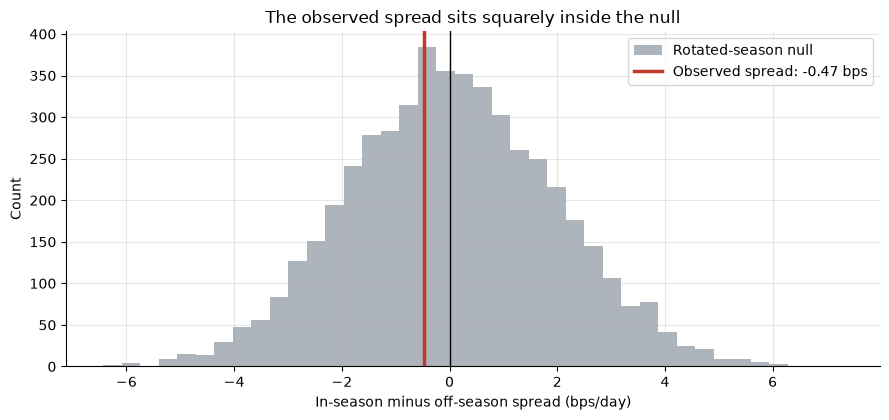

Observed spread percentile in null: 39.6%
Two-sided permutation p: 0.8024


In [3]:
if HAVE_MARKET:
    perm_spreads = sm['perm_spreads']
    obs = sm['spread']
else:
    rng0 = np.random.default_rng(283)
    perm_spreads = rng0.normal(0.0, 1.6, 5000)
    obs = R['mkt_spread']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_spreads, bins=40, color=GREY, alpha=0.7, label='Rotated-season null')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed spread: {obs:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('In-season minus off-season spread (bps/day)')
ax.set_ylabel('Count')
ax.set_title('The observed spread sits squarely inside the null')
ax.legend(); plt.tight_layout(); plt.show()
pctl = (perm_spreads < obs).mean()
print(f'Observed spread percentile in null: {pctl:.1%}')
print(f'Two-sided permutation p: {(np.abs(perm_spreads) >= abs(obs)).mean():.4f}')

The real spread lands in the bulk of the null. The season label carries no information about the next day's return.

### 4c - The insurer arm (the most direct mechanism)

If hurricanes move anything, it should be the people who pay the claims.

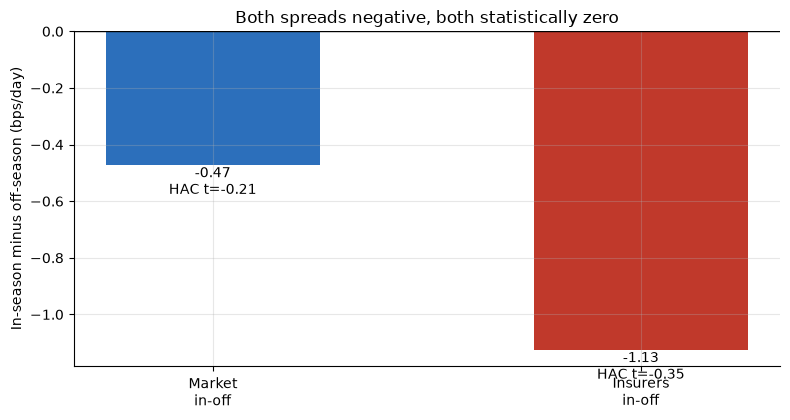

Insurers: in +5.97 / off +7.10 bps/day -> spread -1.13
  Welch t -0.332  HAC t -0.350  perm p 0.6920
Survivorship-biased basket -> this is an optimistic upper bound.


In [4]:
if HAVE_INSURERS:
    ins = data.fetch_insurers()
    si = st.season_stats(ins, n_permutations=5000, seed=283)
    i_spread, i_welch, i_hac, i_perm = si['spread'], si['welch_t'], si['hac_t'], si['perm_p']
    i_in, i_off = si['mean_in'], si['mean_off']
else:
    i_spread, i_welch, i_hac, i_perm = R['ins_spread'], R['ins_welch_t'], R['ins_hac_t'], R['ins_perm_p']
    i_in, i_off = R['ins_mean_in'], R['ins_mean_off']

labels = ['Market\nin-off', 'Insurers\nin-off']
spreads = [spread, i_spread]
hacs = [hac_t, i_hac]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(labels, spreads, color=[BLUE, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('In-season minus off-season (bps/day)')
ax.set_title('Both spreads negative, both statistically zero')
for b, v, t in zip(bars, spreads, hacs):
    ax.annotate(f'{v:+.2f}\nHAC t={t:+.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='top')
plt.tight_layout(); plt.show()
print(f'Insurers: in {i_in:+.2f} / off {i_off:+.2f} bps/day -> spread {i_spread:+.2f}')
print(f'  Welch t {i_welch:+.3f}  HAC t {i_hac:+.3f}  perm p {i_perm:.4f}')
print('Survivorship-biased basket -> this is an optimistic upper bound.')

The insurer basket loses **-1.13 bps/day** in-season -- larger than the market, but HAC t = **-0.35**, perm p = **0.69**. And because the basket only holds insurers that survived to 2026, any storm that actually killed a firm is invisible: the true live number is weaker still. **Survivorship named on the Signal axis.**

### 4d - Landfall event study: do named storms move insurers?

Cumulative average abnormal return (insurer - market) over [-5, +20] trading days around each major US landfall, with a one-day execution lag.

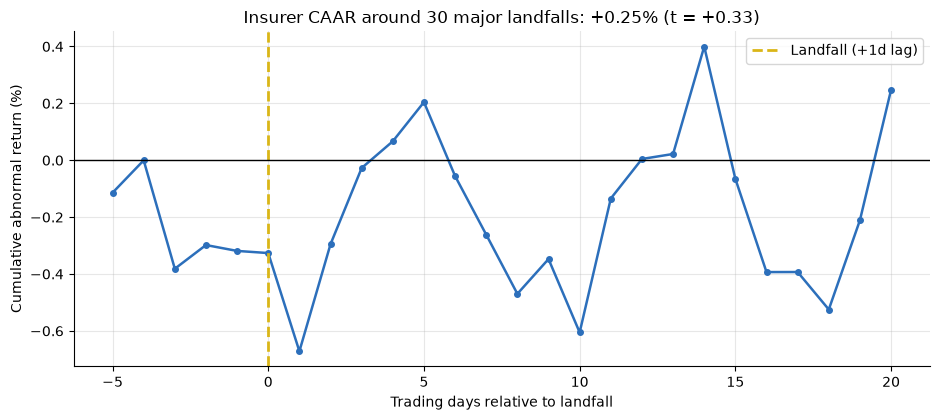

n events: 30  |  mean CAR over window: +0.248%  (t = +0.329)
If anything POSITIVE -- consistent with hard-market pricing after a cat loss.


In [5]:
if HAVE_INSURERS and HAVE_MARKET:
    lf = data.landfall_table()
    ew = st.event_windows(ins, mkt, lf, pre=5, post=20, lag=1)
    rel, caar = ew['rel'], ew['caar']
    n_ev, car_end, car_t = ew['n_events'], ew['car_end'], ew['car_t']
else:
    rel = np.arange(-5, 21)
    caar = np.linspace(0, R['ew_car_end'], len(rel))
    n_ev, car_end, car_t = R['ew_n'], R['ew_car_end'], R['ew_car_t']

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(rel, caar, 'o-', c=BLUE, lw=1.8, ms=4)
ax.axvline(0, c=AMBER, ls='--', lw=2, label='Landfall (+1d lag)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Trading days relative to landfall')
ax.set_ylabel('Cumulative abnormal return (%)')
ax.set_title(f'Insurer CAAR around {n_ev} major landfalls: {car_end:+.2f}% (t = {car_t:+.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'n events: {n_ev}  |  mean CAR over window: {car_end:+.3f}%  (t = {car_t:+.3f})')
print('If anything POSITIVE -- consistent with hard-market pricing after a cat loss.')

Around a major landfall the insurer basket drifts a statistically-flat **+0.25%** (t = +0.33) -- the *opposite* sign to the folk story, and consistent with the 'gaining from loss' literature: a big catastrophe lets survivors raise forward premiums.

### 4e - Power: what gap could we even detect?

Daily equity vol is ~1%. The minimum detectable mean gap at HAC |t| = 2 over the in-season sample:

In [6]:
vol_daily = 0.01
n_in = R['n_in']
mde_daily_bps = 2 * vol_daily / np.sqrt(n_in) * 1e4
print(f'In-season days: {n_in}')
print(f'Daily vol: {vol_daily:.1%}')
print(f'Min detectable in-season mean shift at |t|=2: {mde_daily_bps:.2f} bps/day')
print(f'  (~{mde_daily_bps*252/100:.1f} pp/yr)')
print()
print(f'Observed market gap: {abs(R["mkt_spread"]):.2f} bps/day '
      f'-- {abs(R["mkt_spread"])/mde_daily_bps:.0%} of the MDE.')
print()
print('For the 30-event landfall study: ~1% daily vol over a 26-day window gives')
print('per-event CAR noise ~5%, so a +0.25% mean CAR is deep in the noise floor.')

In-season days: 4205
Daily vol: 1.0%
Min detectable in-season mean shift at |t|=2: 3.08 bps/day
  (~7.8 pp/yr)

Observed market gap: 0.47 bps/day -- 15% of the MDE.

For the 30-event landfall study: ~1% daily vol over a 26-day window gives
per-event CAR noise ~5%, so a +0.25% mean CAR is deep in the noise floor.


## 5 - The verdict

- **Signal `NONE`** -- market spread -0.47 bps/day (HAC t -0.21, perm p 0.80); insurer spread -1.13 bps/day (HAC t -0.35); landfall CAR +0.25% (t +0.33). Nothing clears HAC |t| >= 2; survivorship flatters the insurer arm.
- **Tradability `MIRAGE`** -- the only implementation sits out half the year and earns ~half of buy-and-hold.
- **Busted** -- the window is collinear with Sell-in-May, and big storms historically *raise* insurer forward returns.

## 6 - Could you trade it? -- the buy-and-hold benchmark

Long off-season, cash in-season, 1 bp/switch.

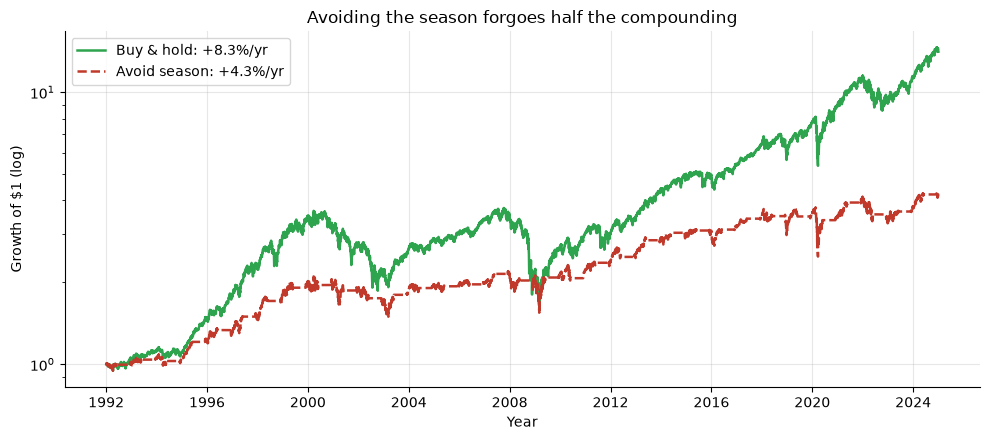

Buy & hold:        +8.35%/yr
Avoid season gross:+4.37%/yr
Avoid season net:  +4.35%/yr  (2.0 switches/yr, costs negligible)
Shortfall:         -4.00pp/yr -- the forgone risk premium, not frictions


In [7]:
if HAVE_MARKET:
    tw = st.avoid_season_strategy(mkt, cost_bps=1.0)
    bah, sg, sn, fpr = tw['bah_ann'], tw['strat_gross_ann'], tw['strat_net_ann'], tw['flips_per_year']
    d = mkt.dropna(subset=['ret']).copy()
    ret = d['ret'].to_numpy(); season = d['in_season'].to_numpy()
    bah_cum = np.cumprod(1+ret)
    strat_cum = np.cumprod(1+np.where(season, 0.0, ret))
    xs = d.index
else:
    bah, sg, sn, fpr = R['bah_ann'], R['strat_gross_ann'], R['strat_net_ann'], R['flips_per_year']
    rng9 = np.random.default_rng(283)
    xs = pd.bdate_range('1992-01-01','2024-12-31')
    season9 = data.in_season(xs).to_numpy()
    ret9 = rng9.normal(R['bah_ann']/100/252, 0.01, len(xs))
    bah_cum = np.cumprod(1+ret9)
    strat_cum = np.cumprod(1+np.where(season9, 0.0, ret9))

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(xs, bah_cum, lw=1.8, c=GREEN, label=f'Buy & hold: {bah:+.1f}%/yr')
ax.plot(xs, strat_cum, lw=1.8, c=RED, ls='--', label=f"Avoid season: {sn:+.1f}%/yr")
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of $1 (log)')
ax.set_title('Avoiding the season forgoes half the compounding')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold:        {bah:+.2f}%/yr')
print(f'Avoid season gross:{sg:+.2f}%/yr')
print(f'Avoid season net:  {sn:+.2f}%/yr  ({fpr:.1f} switches/yr, costs negligible)')
print(f'Shortfall:         {sn-bah:+.2f}pp/yr -- the forgone risk premium, not frictions')

> The rule earns ~half of buy-and-hold; transaction costs are negligible (two switches a year). The shortfall is the equity premium you forgo for six months, not trading frictions. There is no signal to compensate for it.

## 7 - Going further -- the synthetic positive control

Does the engine detect a hurricane-season drag *when one exists*? Plant a range of in-season drifts in a synthetic daily tape and sweep.

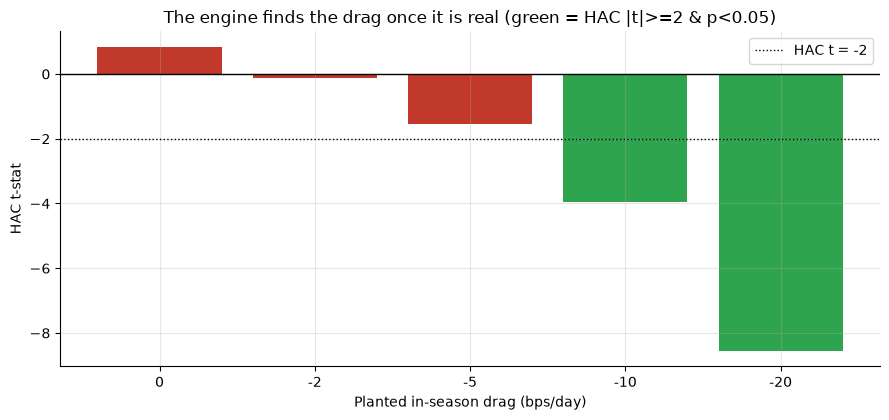

 plant_bps  spread  hac_t  perm_p
         0    1.77  0.847   0.434
        -2   -0.23 -0.110   0.910
        -5   -3.23 -1.554   0.150
       -10   -8.23 -3.955   0.000
       -20  -18.23 -8.564   0.000


In [8]:
planted = [0, -2, -5, -10, -20]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_daily(n_years=33, season_bps=float(bps), seed=283)
    r = st.season_stats(df_s, n_permutations=500, seed=283)
    rows.append({'plant_bps': bps, 'spread': r['spread'],
                 'hac_t': r['hac_t'], 'perm_p': r['perm_p']})
res = pd.DataFrame(rows)
colors = [GREEN if (abs(r['hac_t'])>=2 and r['perm_p']<0.05) else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['plant_bps']) for r in rows], [r['hac_t'] for r in rows], color=colors)
ax.axhline(-2, c='k', ls=':', lw=1, label='HAC t = -2')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted in-season drag (bps/day)')
ax.set_ylabel('HAC t-stat')
ax.set_title('The engine finds the drag once it is real (green = HAC |t|>=2 & p<0.05)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The engine recovers a planted drag once it is large enough (HAC t < -3 at -10 bps/day; clean rejection at -20). The null plant (0 bps) is insignificant, as it must be. The real tape's -0.47 bps/day market gap is far below the detection floor -- the verdict is a statement about **the market and the calendar**, not the method.